In [1]:
!pip install -q transformers torch datasets matplotlib numpy pandas scikit-learn

In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from datasets import load_dataset
from itertools import islice
from PIL import Image
from transformers import AutoImageProcessor, AutoModel
from sklearn.decomposition import PCA

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [3]:
ds = load_dataset(
    "hugging-science/mmu_legacysurvey_dr10_south_21",
    split="train",
    streaming=True
)
samples = list(islice(ds, 200))
print(len(samples))

README.md:   0%|          | 0.00/7.71k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/148957 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/74440 [00:00<?, ?it/s]

200


## Helper functions


In [4]:
def get_flux(s):
    """Return the 4-band flux cube as (4, H, W) = (g, r, i, z)."""
    f = np.array(s["image"]["flux"], dtype=np.float32)
    if f.shape[0] != 4 and f.shape[-1] == 4:
        f = np.transpose(f, (2, 0, 1))
    return f

def stretch(x, lo=1, hi=99):
    """Percentile stretch to [0, 1] so faint galaxy structure is visible."""
    a, b = np.percentile(x, [lo, hi])
    return np.clip((x - a) / (b - a + 1e-8), 0, 1)

def to_pil(im):
    """4-band flux -> RGB PIL image using (i, r, g) as (R, G, B)."""
    r = np.stack([stretch(im[2]), stretch(im[1]), stretch(im[0])], axis=-1)
    return Image.fromarray((r * 255).astype(np.uint8))


## Look at the data

In [5]:
idx = 9
img = get_flux(samples[idx])
print(samples[idx]["image"]["band"])
print(img.shape, img.min(), img.max())

['des-g', 'des-r', 'des-i', 'des-z']
(4, 160, 160) -0.0736784 1.0721577


In [6]:
start = 0
fig, axes = plt.subplots(5, 5, figsize=(14, 14))
for k, ax in enumerate(axes.flat):
    i = start + k
    ax.imshow(to_pil(get_flux(samples[i])))
    ax.set_title(i)
    ax.axis("off")
plt.show()

Output hidden; open in https://colab.research.google.com to view.

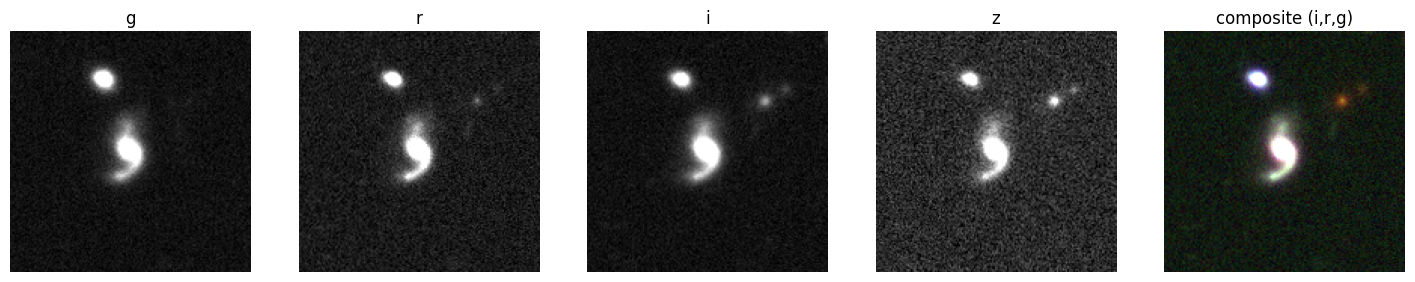

In [7]:
fig, ax = plt.subplots(1, 5, figsize=(18, 4))
for i, name in enumerate(["g", "r", "i", "z"]):
    ax[i].imshow(stretch(img[i]), cmap="gray")
    ax[i].set_title(name)
    ax[i].axis("off")
rgb = np.stack([stretch(img[2]), stretch(img[1]), stretch(img[0])], axis=-1)
ax[4].imshow(rgb)
ax[4].set_title("composite (i,r,g)")
ax[4].axis("off")
plt.show()

## Galaxy Zoo morphology labels



In [8]:

print("Top-level keys:", list(samples[0].keys()))

label_hints = ["smooth", "featured", "spiral", "bar", "bulge", "merg", "gz", "zoo", "morph"]
gz_like = [k for k in samples[0].keys() if any(h in k.lower() for h in label_hints)]
print("Possible Galaxy Zoo-style columns:", gz_like if gz_like else "none (images + Legacy Survey measurements only)")

coord_keys = [k for k in samples[0].keys() if k.lower() in ("ra", "dec", "object_id")]
print("Cross-match keys available:", coord_keys)

import pandas as pd
gz_questions = pd.DataFrame({
    "question": ["smooth-or-featured", "disk-edge-on", "has-spiral-arms", "bar", "bulge-size",
                 "how-rounded", "edge-on-bulge", "spiral-winding", "spiral-arm-count", "merging"],
    "answers": ["smooth / featured-or-disk / artifact", "yes / no", "yes / no", "strong / weak / no",
                "dominant / large / moderate / small / none", "round / in-between / cigar-shaped",
                "boxy / none / rounded", "tight / medium / loose",
                "1 / 2 / 3 / 4 / more than 4 / cannot tell",
                "none / minor-disturbance / major-disturbance / merger"],
})
display(gz_questions)


Top-level keys: ['_healpix_29', 'image', 'blobmodel', 'rgb', 'object_mask', 'catalog', 'EBV', 'FLUX_G', 'FLUX_R', 'FLUX_I', 'FLUX_Z', 'FLUX_W1', 'FLUX_W2', 'FLUX_W3', 'FLUX_W4', 'SHAPE_R', 'SHAPE_E1', 'SHAPE_E2', 'object_id', 'ra', 'dec']
Possible Galaxy Zoo-style columns: none (images + Legacy Survey measurements only)
Cross-match keys available: ['object_id', 'ra', 'dec']


,question,answers
0,smooth-or-featured,smooth / featured-or-disk / artifact
1,disk-edge-on,yes / no
2,has-spiral-arms,yes / no
3,bar,strong / weak / no
4,bulge-size,dominant / large / moderate / small / none
5,how-rounded,round / in-between / cigar-shaped
6,edge-on-bulge,boxy / none / rounded
7,spiral-winding,tight / medium / loose
8,spiral-arm-count,1 / 2 / 3 / 4 / more than 4 / cannot tell
9,merging,none / minor-disturbance / major-disturbance /...


In [9]:
gz = load_dataset("MultimodalUniverse/gz10", split="train", streaming=True)
gz_samples = list(islice(gz, 500))
print(gz_samples[0].keys())

gz_classes = {
    0: "Disturbed",
    1: "Merging",
    2: "Round Smooth",
    3: "In-between Round Smooth",
    4: "Cigar Shaped Smooth",
    5: "Barred Spiral",
    6: "Unbarred Tight Spiral",
    7: "Unbarred Loose Spiral",
    8: "Edge-on without Bulge",
    9: "Edge-on with Bulge",
}

label_key = [k for k in gz_samples[0].keys() if "label" in k.lower() or k.lower() == "ans"]
print(label_key)
if label_key:
    labs = [s[label_key[0]] for s in gz_samples]
    print(pd.Series(labs).map(gz_classes).value_counts())

README.md:   0%|          | 0.00/5.27k [00:00<?, ?B/s]

dict_keys(['gz10_label', 'redshift', 'object_id', 'rgb_image', 'rgb_pixel_scale'])
['gz10_label']
Round Smooth               85
Edge-on with Bulge         79
Barred Spiral              68
Merging                    62
Unbarred Tight Spiral      54
Disturbed                  40
Edge-on without Bulge      37
In-between Round Smooth    32
Unbarred Loose Spiral      22
Cigar Shaped Smooth        21
Name: count, dtype: int64


## Load DINOv2 and preprocess

In [10]:
model_name = "facebook/dinov2-small"
processor = AutoImageProcessor.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device).eval()
print(sum(p.numel() for p in model.parameters()) / 1e6, "M params")

preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 88.2MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

22.056576 M params


In [11]:
pil_img = to_pil(img)
inputs = processor(images=pil_img, return_tensors="pt").to(device)
print(inputs["pixel_values"].shape)

torch.Size([1, 3, 224, 224])


## Inference and token structure

In [12]:
with torch.no_grad():
    out = model(**inputs)

tokens = out.last_hidden_state
print(tokens.shape)

torch.Size([1, 257, 384])


In [13]:
print(out.keys())
print(out.last_hidden_state.shape)
print(out.pooler_output.shape)

odict_keys(['last_hidden_state', 'pooler_output'])
torch.Size([1, 257, 384])
torch.Size([1, 384])


In [14]:
cls_token = tokens[:, 0]
print(cls_token.shape)

torch.Size([1, 384])


In [15]:
patch_tokens = tokens[:, 1:]
print(patch_tokens.shape)

torch.Size([1, 256, 384])


In [16]:
print("all tokens:", tokens.shape)
print("cls token:", cls_token.shape)
print("patch tokens:", patch_tokens.shape)
print("grid:", int(patch_tokens.shape[1] ** 0.5), "x", int(patch_tokens.shape[1] ** 0.5))
print("embedding dim:", patch_tokens.shape[-1])

all tokens: torch.Size([1, 257, 384])
cls token: torch.Size([1, 384])
patch tokens: torch.Size([1, 256, 384])
grid: 16 x 16
embedding dim: 384


## Patch-token and embedding exploration

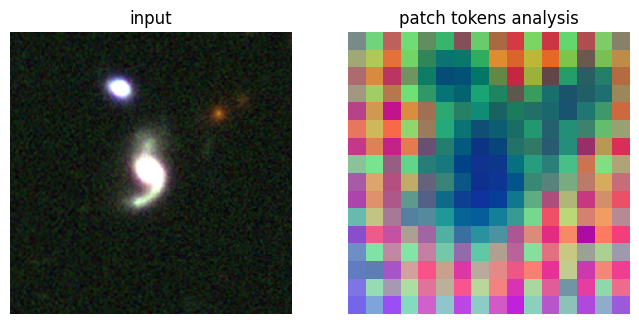

In [17]:
p = patch_tokens[0].cpu().numpy()
pc = PCA(n_components=3).fit_transform(p).reshape(16, 16, 3)
pc = (pc - pc.min()) / (pc.max() - pc.min())

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(pil_img.resize((224, 224)))
ax[0].set_title("input")
ax[1].imshow(pc)
ax[1].set_title("patch tokens analysis")
for a in ax:
    a.axis("off")
plt.show()

(200, 384)


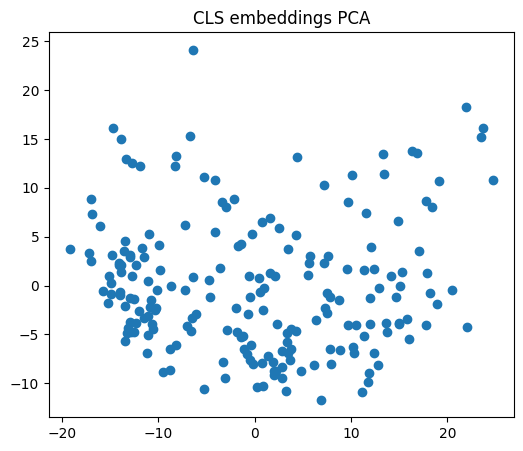

In [18]:
embs = []
for s in samples:
    x = processor(images=to_pil(get_flux(s)), return_tensors="pt").to(device)
    with torch.no_grad():
        embs.append(model(**x).last_hidden_state[:, 0].cpu().numpy()[0])
embs = np.array(embs)
print(embs.shape)

xy = PCA(n_components=2).fit_transform(embs)
plt.figure(figsize=(6, 5))
plt.scatter(xy[:, 0], xy[:, 1])
plt.title("CLS embeddings PCA")
plt.show()

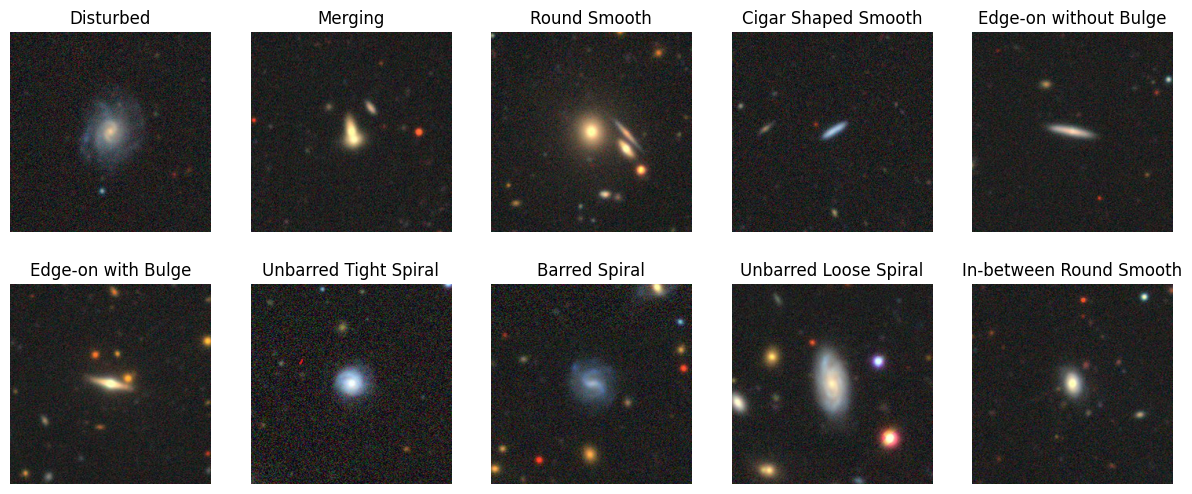

In [19]:
def gz_to_pil(s):
    im = s["rgb_image"]
    if isinstance(im, Image.Image):
        return im.convert("RGB")
    return Image.fromarray(np.array(im).astype(np.uint8)).convert("RGB")

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
shown = set()
for s in gz_samples:
    l = s["gz10_label"]
    if l not in shown and len(shown) < 10:
        ax = axes.flat[len(shown)]
        ax.imshow(gz_to_pil(s))
        ax.set_title(gz_classes[l])
        ax.axis("off")
        shown.add(l)
plt.show()

(500, 384)


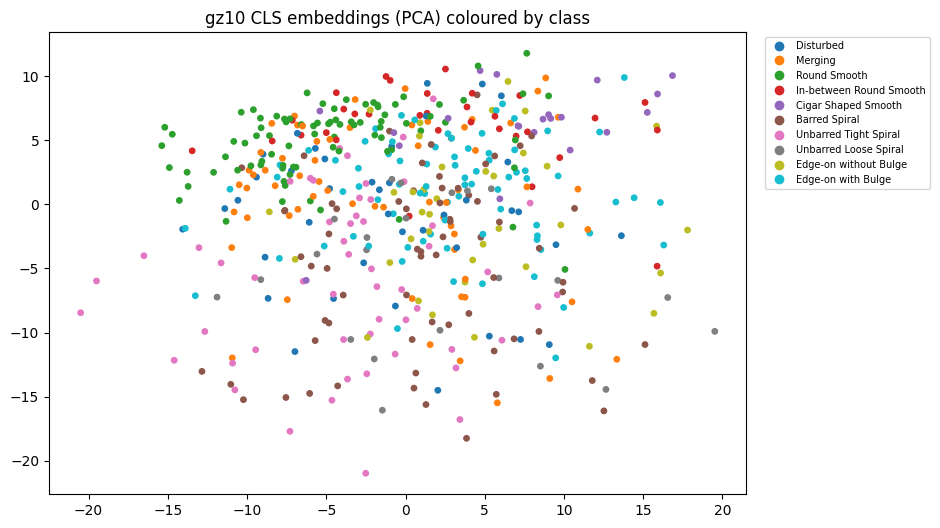

In [20]:
gz_embs, gz_labs = [], []
for s in gz_samples:
    x = processor(images=gz_to_pil(s), return_tensors="pt").to(device)
    with torch.no_grad():
        gz_embs.append(model(**x).last_hidden_state[:, 0].cpu().numpy()[0])
    gz_labs.append(s["gz10_label"])
gz_embs = np.array(gz_embs)
gz_labs = np.array(gz_labs)
print(gz_embs.shape)

xy = PCA(n_components=2).fit_transform(gz_embs)
plt.figure(figsize=(9, 6))
sc = plt.scatter(xy[:, 0], xy[:, 1], c=gz_labs, cmap="tab10", s=15)
plt.legend(handles=sc.legend_elements()[0], labels=[gz_classes[i] for i in range(10)], fontsize=7, bbox_to_anchor=(1.02, 1))
plt.title("gz10 CLS embeddings (PCA) coloured by class")
plt.show()